In [63]:
import torch
from torch import nn
import matplotlib.pyplot as plt

print(torch.__version__)

2.12.0+cpu


In [64]:
weight = 0.7
bias = 0.3

In [65]:
start = 0
end = 1
step = 0.1
X = torch.arange(start,end,step).unsqueeze(dim=1)
y = weight * X +bias

In [66]:
X[:10]

tensor([[0.0000],
        [0.1000],
        [0.2000],
        [0.3000],
        [0.4000],
        [0.5000],
        [0.6000],
        [0.7000],
        [0.8000],
        [0.9000]])

In [67]:
y[:10]

tensor([[0.3000],
        [0.3700],
        [0.4400],
        [0.5100],
        [0.5800],
        [0.6500],
        [0.7200],
        [0.7900],
        [0.8600],
        [0.9300]])

In [68]:
len(X), len(y)

(10, 10)

In [69]:
number_of_training = (0.8 * len(X))
int(number_of_training)

8

In [70]:
X_train,y_train = X[:int(number_of_training)], y[:int(number_of_training)]
X_test, y_test = X[int(number_of_training):], y[int(number_of_training):]
len(X_train), len(y_train), len(X_test), len(y_test)

(8, 8, 2, 2)

In [71]:
def plot_data(train_data=X_train, train_label=y_train, test_data=X_test, test_label=y_test, prediction=None):
    plt.figure(figsize=(10,7))
    plt.scatter(train_data, train_label, c="b", s=4, label="trainning data")
    plt.scatter(test_data, test_label, c="y", s=4, label="test data")
    if prediction is not None:
        plt.scatter(test_data, prediction, c="r", s=4, label="Predictions")

    plt.legend(prop={"size":14})

    

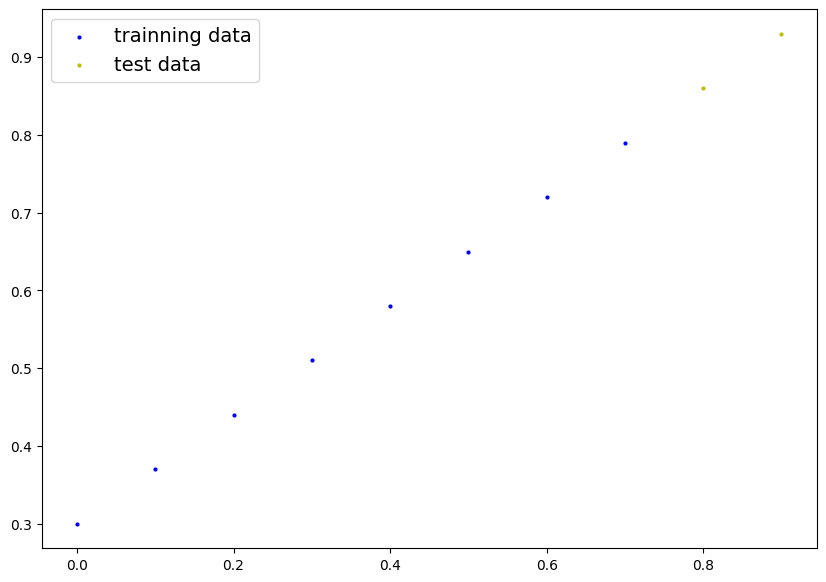

In [72]:
plot_data()

In [73]:
class LinearRegressionModel(nn.Module):

    def __init__(self):
        super().__init__()
        self.weight = nn.Parameter(torch.randn(1, requires_grad=True, dtype=torch.float32))
        self.bias = nn.Parameter(torch.randn(1, requires_grad=True, dtype=torch.float32))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.weight * x + self.bias
    

In [74]:
torch.manual_seed(42)
model_0 = LinearRegressionModel()
loss_fn = nn.L1Loss()
optimizer = torch.optim.SGD(params=model_0.parameters(), lr=0.01)
list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [75]:
model_0.state_dict()

OrderedDict([('weight', tensor([0.3367])), ('bias', tensor([0.1288]))])

In [76]:
X_test

tensor([[0.8000],
        [0.9000]])

In [77]:
y_test

tensor([[0.8600],
        [0.9300]])

In [78]:
with torch.inference_mode():
    y_preds = model_0(X_test)
y_preds

tensor([[0.3982],
        [0.4318]])

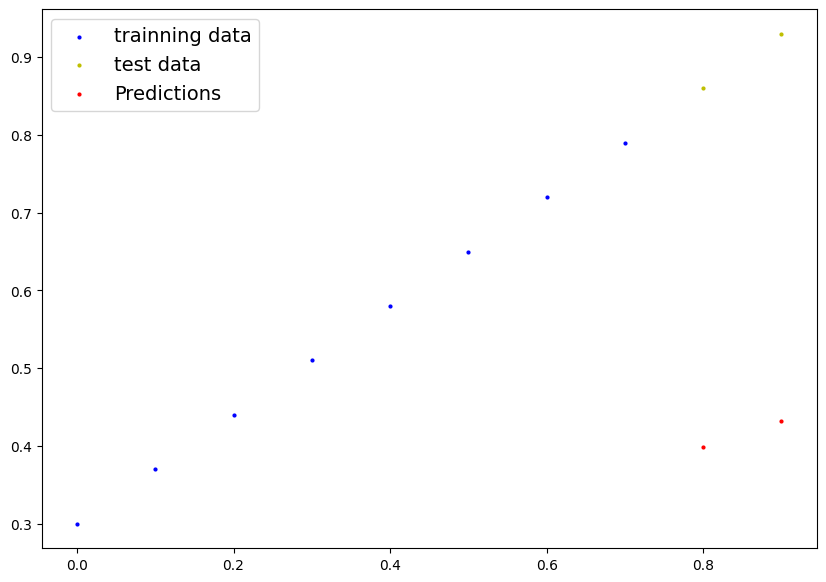

In [79]:
plot_data(prediction=y_preds)

In [80]:
epochs = 200

for epoch in range(epochs):
    model_0.train()
    
    y_preds = model_0(X_train)
    
    loss = loss_fn(y_preds, y_train)
    
    optimizer.zero_grad()

    loss.backward()

    optimizer.step()
    
    optimizer.zero_grad()
    
    # print(f"Epoch: {epoch} | Loss: {loss} | Weight: {model_0.weight.item()} | Bias: {model_0.bias.item()}")

    model_0.eval()
    with torch.inference_mode():
        test_preds = model_0(X_test)
        test_loss = loss_fn(test_preds, y_test)
    if epoch % 10 == 0:
        print(f"Epoch: {epoch} | Loss: {loss} | Test Loss: {test_loss} | Weight: {model_0.weight.item()} | Bias: {model_0.bias.item()}")


Epoch: 0 | Loss: 0.29834896326065063 | Test Loss: 0.46702879667282104 | Weight: 0.3401903808116913 | Bias: 0.1388094127178192
Epoch: 10 | Loss: 0.1860988587141037 | Test Loss: 0.3372786045074463 | Weight: 0.37519052624702454 | Bias: 0.2388094663619995
Epoch: 20 | Loss: 0.08480121195316315 | Test Loss: 0.2150285243988037 | Weight: 0.4101906716823578 | Bias: 0.33130940794944763
Epoch: 30 | Loss: 0.05562645569443703 | Test Loss: 0.15202853083610535 | Weight: 0.44019073247909546 | Bias: 0.36880937218666077
Epoch: 40 | Loss: 0.04791184514760971 | Test Loss: 0.1256159543991089 | Weight: 0.4624407887458801 | Bias: 0.3763093650341034
Epoch: 50 | Loss: 0.04391184076666832 | Test Loss: 0.1086159348487854 | Weight: 0.4824408292770386 | Bias: 0.3763093650341034
Epoch: 60 | Loss: 0.03991183638572693 | Test Loss: 0.0916159451007843 | Weight: 0.5024408102035522 | Bias: 0.3763093650341034
Epoch: 70 | Loss: 0.03631187602877617 | Test Loss: 0.08131614327430725 | Weight: 0.5204405784606934 | Bias: 0.3713

In [81]:
model_0.state_dict()

OrderedDict([('weight', tensor([0.6912])), ('bias', tensor([0.3063]))])

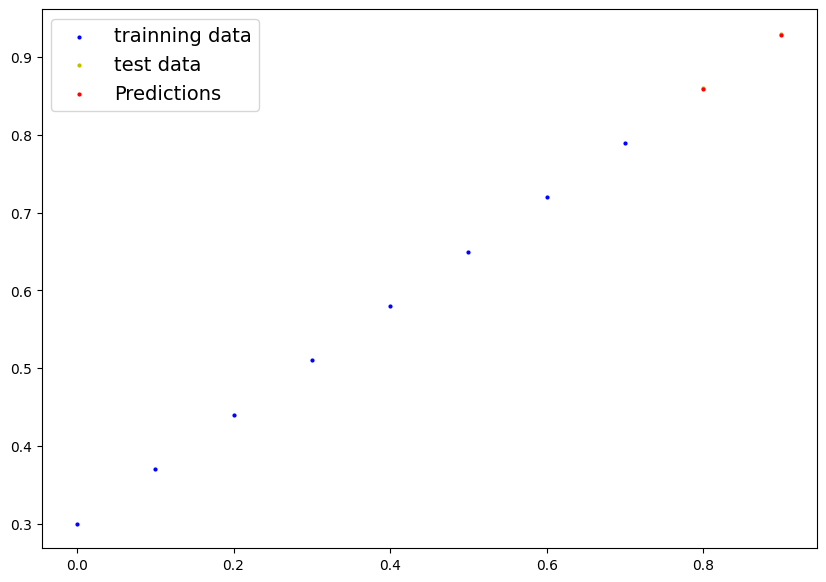

In [82]:
with torch.inference_mode():
    y_preds_news = model_0(X_test)

plot_data(prediction=y_preds_news)